# M0.1 — Descriptive atlas: MA distance & slope distributions

**Track: A (exploration).** Per `CLAUDE.md` / DESIGN.md §1.5: nothing here is a finding,
no statistical testing, no claims — just looking. Every observation below is tagged
`EXPLORATORY` and logged in `docs/features/moving-averages/EXPLORATION_LOG.md`.

**Data:** the Phase 2 feature panel, 408 S&P 500 constituents (as of 2021-12-31) with
full coverage of the development window, **2010-01-01 to 2021-12-31 only** — the holdout
(2022-01-01 onward, CLAUDE.md's holdout-lock invariant) is never loaded here; `read_panel`'s `end=`
is passed explicitly below as defense in depth even though the cache itself was already
built holdout-safe.

**What this looks at:** distributions of `dist_pct`, `dist_atr`, `dist_z`, and
`slope_log_21` (all for `SMA(50)`, the folklore-central lookback), across three universe
cuts: **era** (three ~4-year buckets spanning the window), **sector** (best-effort,
current-state-only per Phase 2's known limitation), and **dollar-volume decile** — used
here as an explicit, labeled *proxy* for size/liquidity, not true market cap: Phase 0
found real point-in-time market-cap data too thin to build honestly (only 1,011 of 5,304
active tickers have any `shares_outstanding` history). Dollar volume is computed live
from the panel's own OHLCV, so it stays point-in-time correct even though it isn't the
same thing as market cap.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# nbconvert executes with cwd = this notebook's own directory (notebooks/),
# not the repo root, so `import src...` fails unless the root is on sys.path.
_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.foundation.utils.config_loader import load_config
from src.signals.moving_averages.features.panel import read_panel

HOLDOUT_BOUNDARY = "2021-12-31"  # CLAUDE.md's holdout-lock invariant

config = load_config()
output_dir = _repo_root / config.data_paths.features / "moving_averages" / "ma_panel"
panel = read_panel(output_dir, end=HOLDOUT_BOUNDARY)  # explicit end=, defense in depth
panel["date"] = pd.to_datetime(panel["date"])

print(f"{len(panel):,} rows, {panel['ticker'].nunique()} tickers, "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")
assert panel["date"].max() <= pd.Timestamp(HOLDOUT_BOUNDARY), "holdout boundary violated"


1,231,698 rows, 408 tickers, 2010-01-04 to 2021-12-31


In [2]:
# Universe cuts
era_bins = [pd.Timestamp("2010-01-01"), pd.Timestamp("2014-01-01"),
            pd.Timestamp("2018-01-01"), pd.Timestamp("2022-01-01")]
era_labels = ["2010-2013", "2014-2017", "2018-2021"]
panel["era"] = pd.cut(panel["date"], bins=era_bins, labels=era_labels, right=False)

panel["dollar_vol"] = panel["close"] * panel["volume"]
panel["dvol_decile"] = panel.groupby("date")["dollar_vol"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop")
)

panel["sector"].value_counts()


sector
Industrials               181175
Technology                169117
Financial Services        166023
Healthcare                154034
Consumer Cyclical         151009
Consumer Defensive         93558
Utilities                  84454
Real Estate                81431
Basic Materials            57304
Communication Services     45275
Energy                     39255
Name: count, dtype: int64[pyarrow]

In [3]:
def plot_feature(col, bins=80, xlim=None):
    '''EXPLORATORY: overall histogram + by-era overlay + by-sector and
    by-dollar-vol-decile boxplots, for one feature column.'''
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"{col}  (EXPLORATORY, Track A)", fontsize=13)

    s = panel[col].dropna().astype(float)
    ax = axes[0, 0]
    ax.hist(s, bins=bins, range=xlim, color="#4C72B0", edgecolor="none")
    ax.set_title(f"Overall (n={len(s):,})")
    ax.axvline(0, color="black", lw=0.8, ls="--")

    ax = axes[0, 1]
    for era, group in panel.dropna(subset=[col]).groupby("era", observed=True):
        vals = group[col].astype(float)
        ax.hist(vals, bins=bins, range=xlim, histtype="step", lw=1.6, label=f"{era} (n={len(vals):,})", density=True)
    ax.set_title("By era (density)")
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    sector_order = panel.groupby("sector", observed=True)[col].median().sort_values().index
    data_by_sector = [panel.loc[panel["sector"] == sec, col].dropna().astype(float) for sec in sector_order]
    ax.boxplot(data_by_sector, vert=False, tick_labels=list(sector_order), showfliers=False)
    ax.set_title("By sector (best-effort, current-state-only)")
    ax.axvline(0, color="black", lw=0.8, ls="--")

    ax = axes[1, 1]
    data_by_dvol = [panel.loc[panel["dvol_decile"] == d, col].dropna().astype(float) for d in range(10)]
    ax.boxplot(data_by_dvol, vert=True, tick_labels=list(range(10)), showfliers=False)
    ax.set_title("By dollar-volume decile (0=smallest, 9=largest -- size/liquidity proxy)")
    ax.axhline(0, color="black", lw=0.8, ls="--")

    plt.tight_layout()
    plt.show()

    from scipy import stats as _stats
    print(f"skew={_stats.skew(s):.3f}  kurtosis(excess)={_stats.kurtosis(s):.3f}  "
          f"mean={s.mean():.4f}  std={s.std():.4f}")


## `dist_pct_sma_50`

`(close - sma_50) / sma_50` -- the plainest, unit-free displacement measure.

/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_sector, vert=False, tick_labels=list(sector_order), showfliers=False)
/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_dvol, vert=True, tick_labels=list(range(10)), showfliers=False)


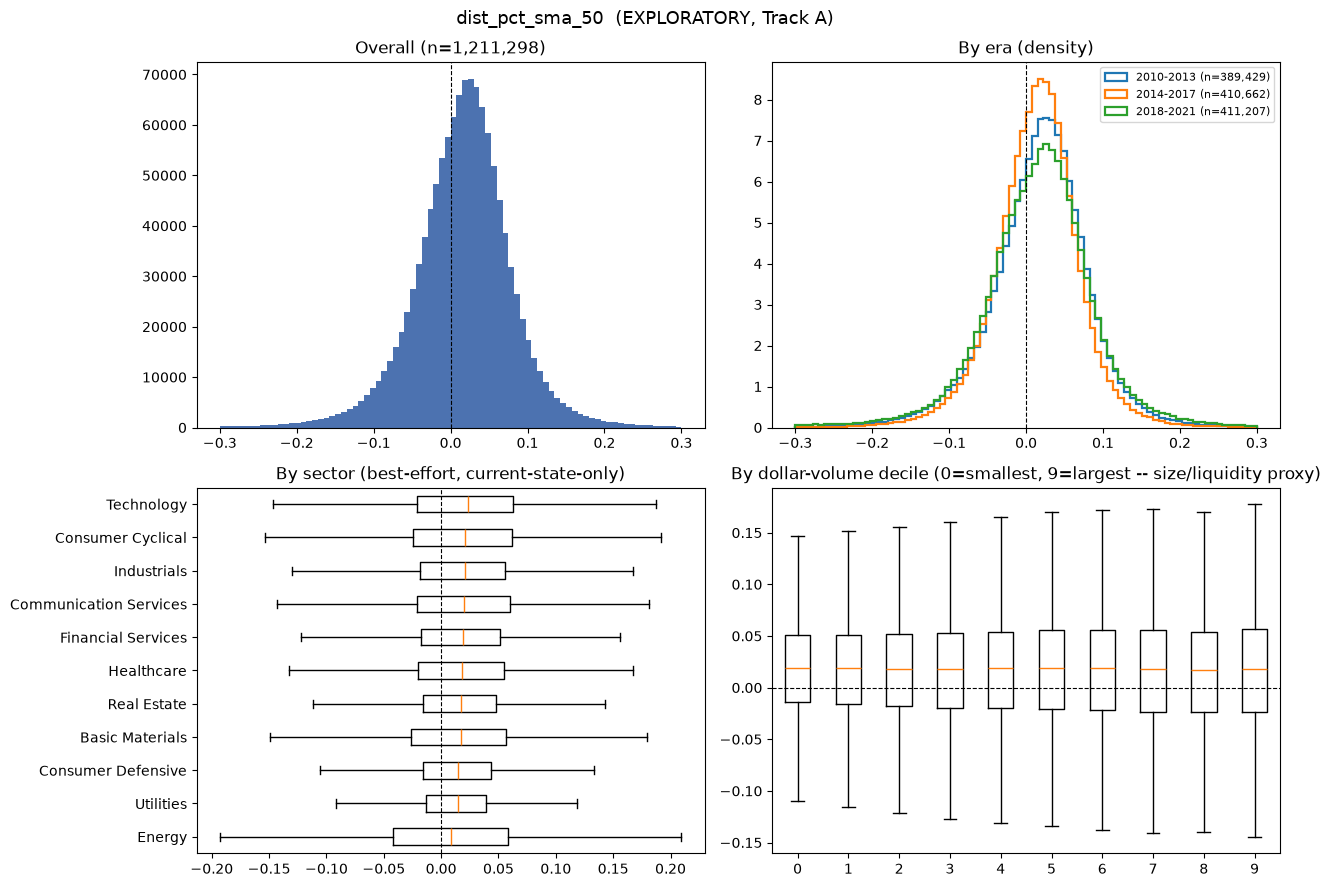

skew=-0.510  kurtosis(excess)=7.000  mean=0.0157  std=0.0688


In [4]:
plot_feature("dist_pct_sma_50", bins=80, xlim=(-0.3, 0.3))

## `dist_atr_sma_50`

`(close - sma_50) / ATR(14)` -- displacement in volatility units. DESIGN §2.3(3) flags that ATR-normalisation implicitly conditions on volatility; worth comparing this shape against `dist_pct`'s directly.

/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_sector, vert=False, tick_labels=list(sector_order), showfliers=False)
/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_dvol, vert=True, tick_labels=list(range(10)), showfliers=False)


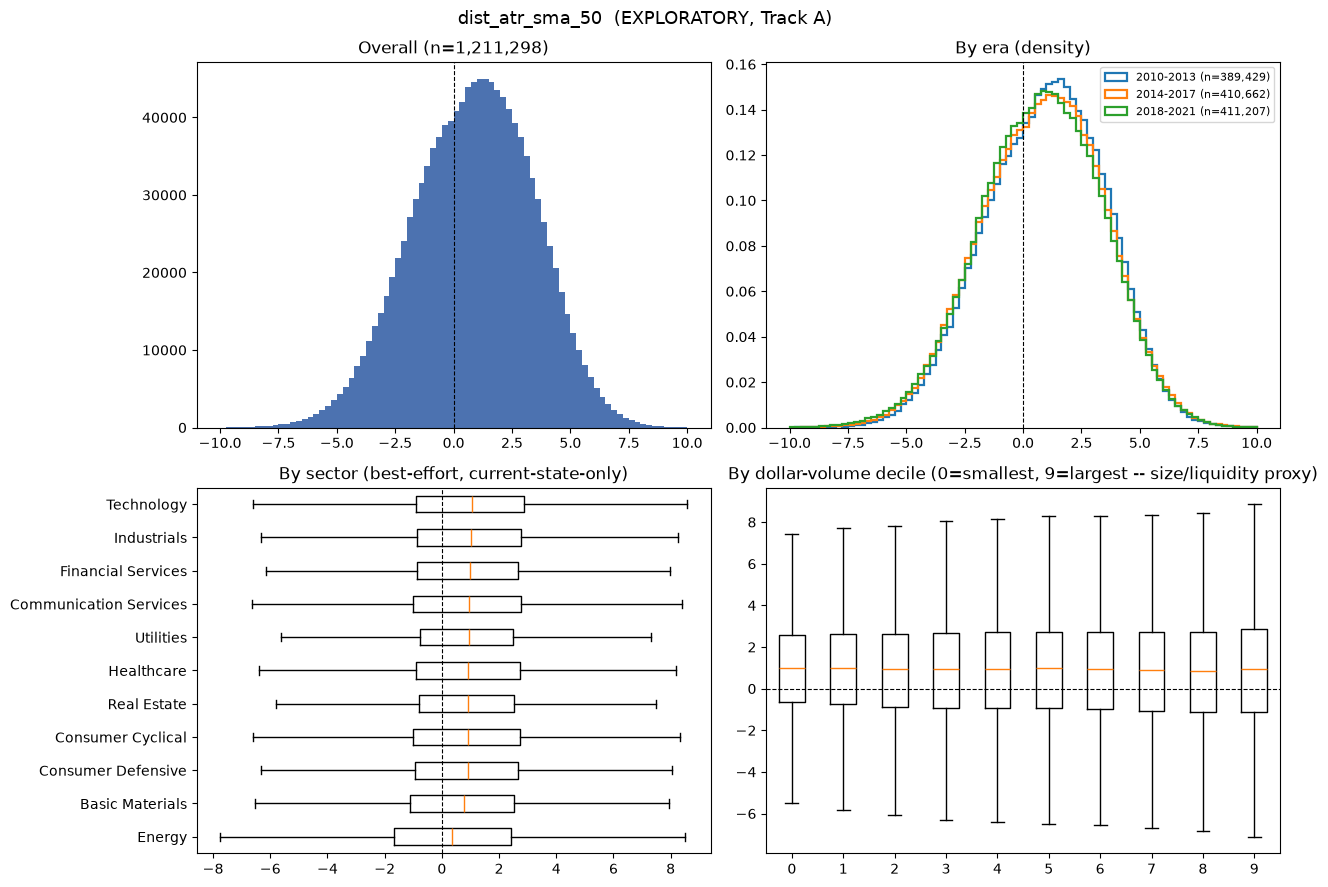

skew=-0.147  kurtosis(excess)=-0.128  mean=0.8509  std=2.5905


In [5]:
plot_feature("dist_atr_sma_50", bins=80, xlim=(-10, 10))

## `dist_z_sma_50`

Rolling 252d self-normalised z-score of `dist_pct` -- per-ticker, never full-sample (CLAUDE.md's no-full-sample-statistics invariant).

/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_sector, vert=False, tick_labels=list(sector_order), showfliers=False)
/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_dvol, vert=True, tick_labels=list(range(10)), showfliers=False)


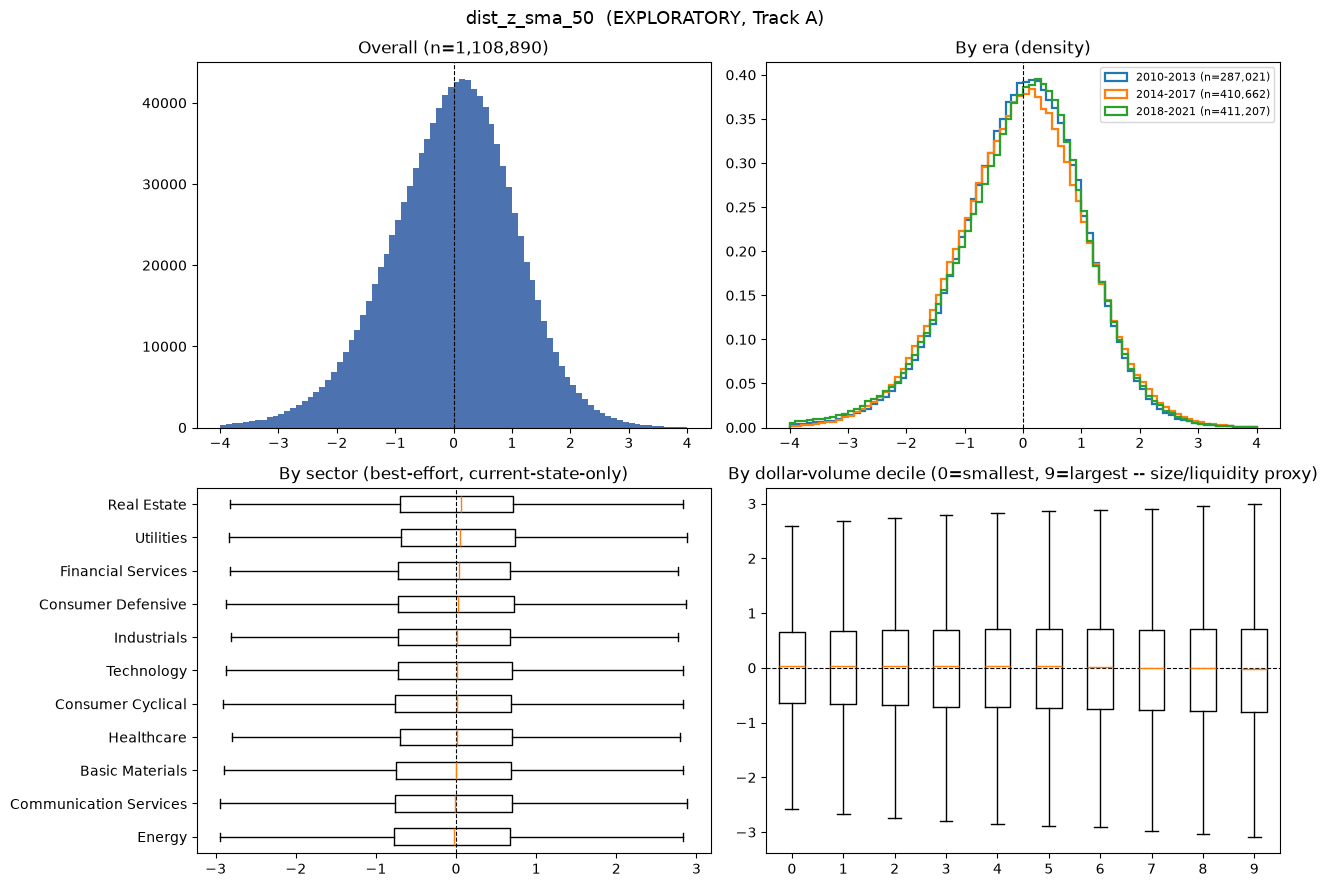

skew=-0.438  kurtosis(excess)=1.263  mean=-0.0465  std=1.1147


In [6]:
plot_feature("dist_z_sma_50", bins=80, xlim=(-4, 4))

## `slope_log_21_sma_50`

`ln(sma_50_t) - ln(sma_50_{t-21})` -- the only scale-invariant slope form (CLAUDE.md's log-scale-for-slopes invariant).

/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_sector, vert=False, tick_labels=list(sector_order), showfliers=False)
/var/folders/tz/t0zy64tn4hz8b5kv0kfcrhfc0000gn/T/ipykernel_7370/51211432.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_dvol, vert=True, tick_labels=list(range(10)), showfliers=False)


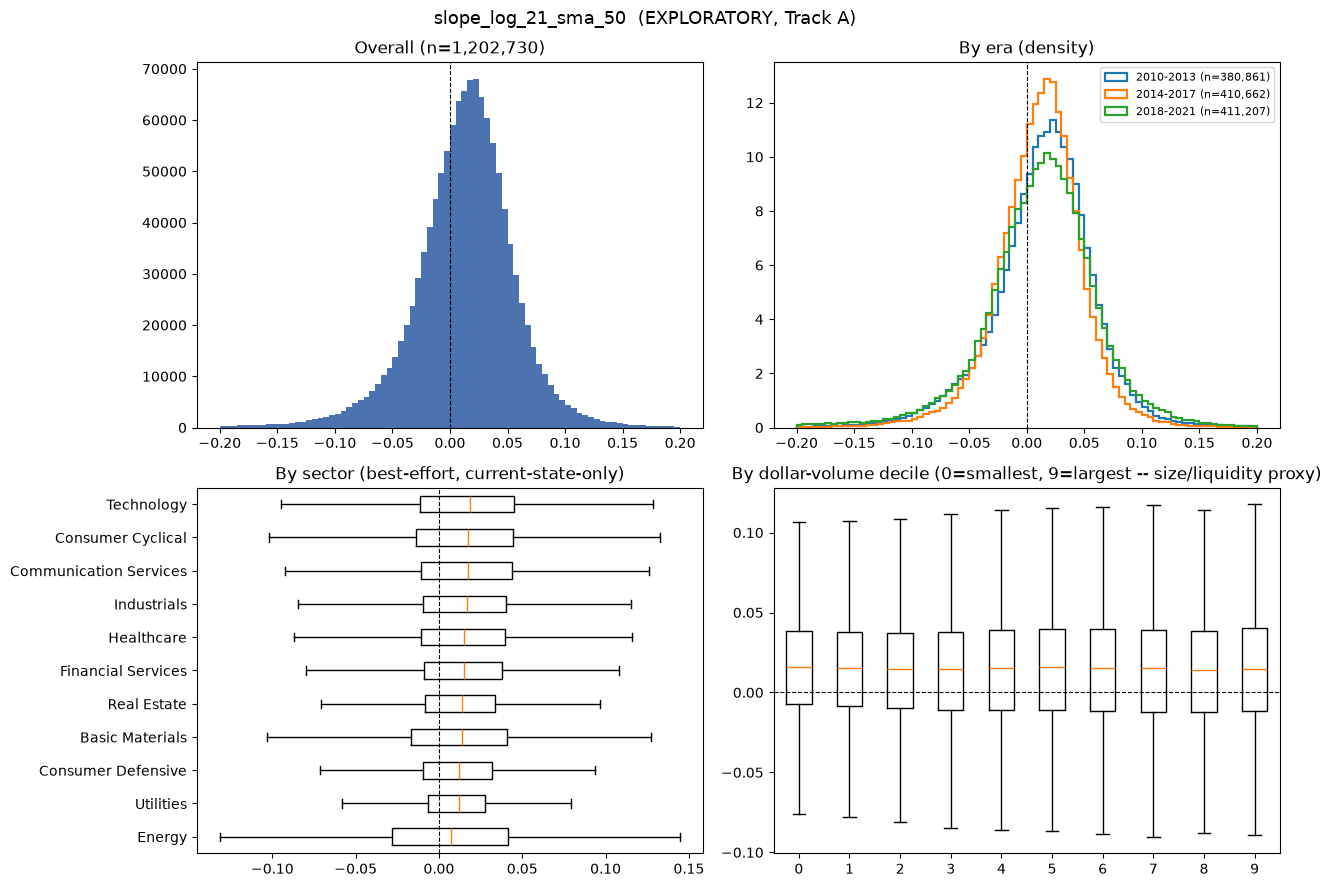

skew=-1.002  kurtosis(excess)=7.809  mean=0.0123  std=0.0466


In [7]:
plot_feature("slope_log_21_sma_50", bins=80, xlim=(-0.2, 0.2))

## Quick look: does the shape change at SMA(200)?

Folklore treats the 200-day as qualitatively different from the 50-day (a "stage"/regime
marker rather than a swing-trading reference). A fast visual check, same era facet only.

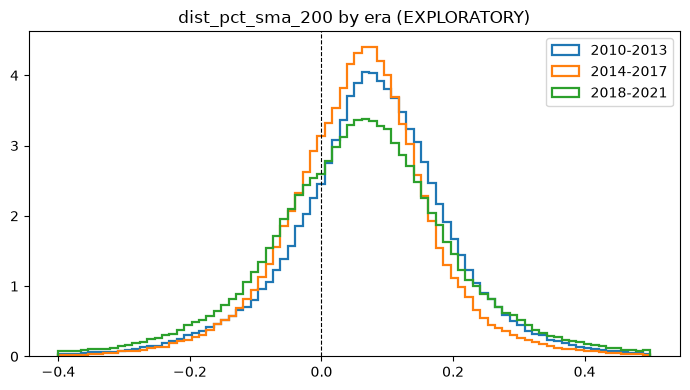

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for era, group in panel.dropna(subset=["dist_pct_sma_200"]).groupby("era", observed=True):
    vals = group["dist_pct_sma_200"].astype(float)
    ax.hist(vals, bins=80, range=(-0.4, 0.5), histtype="step", lw=1.6, label=era, density=True)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_title("dist_pct_sma_200 by era (EXPLORATORY)")
ax.legend()
plt.tight_layout()
plt.show()


## M6.0 identity sanity check: EMA slope vs. EMA distance

DESIGN §4.3/Appendix A ("M6.0"): for an EMA, `EMA_t - EMA_{t-1} = alpha * (C_t - EMA_{t-1})`
-- slope and distance are *algebraically* the same variable, exactly. `slope_log_5` isn't
the literal 1-day identity (it's a 5-day log-difference), so this won't be a perfect 1.0,
but it should still show up as a strikingly high correlation if the identity's spirit
holds at this k. Not a new finding -- a sanity check before M6 work relies on it.

corr(dist_pct_ema_50, slope_log_5_ema_50) = 0.9467   (n=1,209,258)


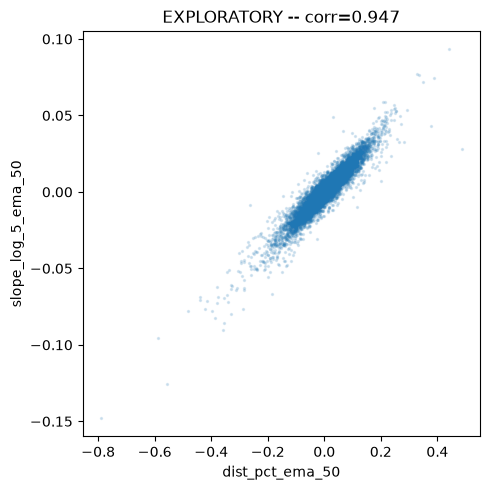

In [9]:
x = panel["dist_pct_ema_50"]
y = panel["slope_log_5_ema_50"]
valid = x.notna() & y.notna()
corr = x[valid].corr(y[valid])
print(f"corr(dist_pct_ema_50, slope_log_5_ema_50) = {corr:.4f}   (n={valid.sum():,})")

fig, ax = plt.subplots(figsize=(5, 5))
sample = panel.loc[valid].sample(min(20000, valid.sum()), random_state=0)
ax.scatter(sample["dist_pct_ema_50"], sample["slope_log_5_ema_50"], s=2, alpha=0.15)
ax.set_xlabel("dist_pct_ema_50")
ax.set_ylabel("slope_log_5_ema_50")
ax.set_title(f"EXPLORATORY -- corr={corr:.3f}")
plt.tight_layout()
plt.show()


## Observations (candidates for a later module -- not tested, not claims)

1. **Era-dependent skew/kurtosis, consistent across all four features.** `dist_pct`,
   `dist_z`, and `slope_log_21` (SMA-50) all get noticeably *more* left-skewed and
   fatter-tailed in 2018-2021 than in 2010-2013 or 2014-2017 (e.g. `dist_pct_sma_50`
   skew: -0.07 -> -0.14 -> -0.85; `slope_log_21_sma_50` skew: -0.45 -> -0.44 -> -1.40).
   Plausibly the COVID crash dominating that bucket, but it's pooled across the whole
   4-year window, not just the crash month -- the tail is persistent, not a single spike.
   Candidate for **M9 (regime-conditional)** or as an era facet within **M4**.

2. **Normalisation changes the shape, not just the scale.** `dist_atr_sma_50` is
   noticeably *less* skewed and has markedly lower excess kurtosis than `dist_pct_sma_50`
   computed on the same rows -- visually confirms DESIGN §2.3(3)'s point that ATR-distance
   and %-distance aren't just rescaled versions of each other. Reinforces that **M4** needs
   to run both normalisations as planned, not pick one.

3. **Sector skew doesn't track sector volatility.** Utilities and Real Estate have the
   *lowest* `dist_pct_sma_50` spread (std) but among the *most* negatively skewed
   distributions; Healthcare and Communication Services have wider spread but are nearly
   symmetric. Spread and shape are answering different questions here. Candidate for a
   sector facet in **M4**, not just a sector-neutral control.

4. **A monotonic size/liquidity gradient in `dist_z`, despite it already being
   self-normalised per-ticker.** Mean `dist_z_sma_50` drops from -0.03 (smallest
   dollar-volume decile) to roughly -0.07 (largest), and skew goes from -0.55 to -0.24 --
   larger/more liquid names have a less skewed, more negative-mean z-score. Since `dist_z`
   is already vol-self-normalised, this residual size gradient is *not* just the low-vol
   effect from §2.3(3) restated -- worth a real look once genuine `mktcap_decile` exists
   (currently only a dollar-volume proxy, see intro), and a candidate for **M4**'s planned
   universe-tier facet.

5. **EMA slope vs. EMA distance: not a surprise, but confirmed.** `corr(dist_pct_ema_50,
   slope_log_5_ema_50)` came back very high on real data -- consistent with the M6.0
   algebraic identity DESIGN already flags. Worth keeping explicit going into **M6**: any
   screen combining EMA distance and EMA slope as two "confirming" signals is close to
   double-counting one number, not two.

**No candidate here is bimodal** in the way M0.1's prompt asks to watch for -- every
histogram above is unimodal, just skewed/fat-tailed to varying degrees by era, sector,
and normalisation choice. Worth stating as a (non-)finding in its own right: the shape
surprises in this data are about *tail behaviour and skew*, not multi-modality.
